## ALGORITMO WHITE-PATCH

Implementar el algoritmo White Patch para librarnos de las diferencias de color de iluminación:

### Solución:
El algoritmo **White Patch** (o **Max-RGB**) es una forma simple de balance de blancos:

$$
R' = \frac{255}{\max(R)} \cdot R ,

G' = \frac{255}{\max(G)} \cdot G ,

B' = \frac{255}{\max(B)} \cdot B ,
$$

In [4]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

def white_patch(img_bgr):
    # Convertir a float para evitar overflow
    img = img_bgr.astype(np.float32)

    # OpenCV usa BGR, no RGB
    b_max = np.max(img[:, :, 0])
    g_max = np.max(img[:, :, 1])
    r_max = np.max(img[:, :, 2])

    # Evitar división por cero
    b_scale = 255.0 / b_max if b_max > 0 else 1.0
    g_scale = 255.0 / g_max if g_max > 0 else 1.0
    r_scale = 255.0 / r_max if r_max > 0 else 1.0

    # Escalar cada canal
    img[:, :, 0] *= b_scale
    img[:, :, 1] *= g_scale
    img[:, :, 2] *= r_scale

    # Limitar al rango válido y volver a uint8
    return np.clip(img, 0, 255).astype(np.uint8)
    


Encontradas 8 imágenes


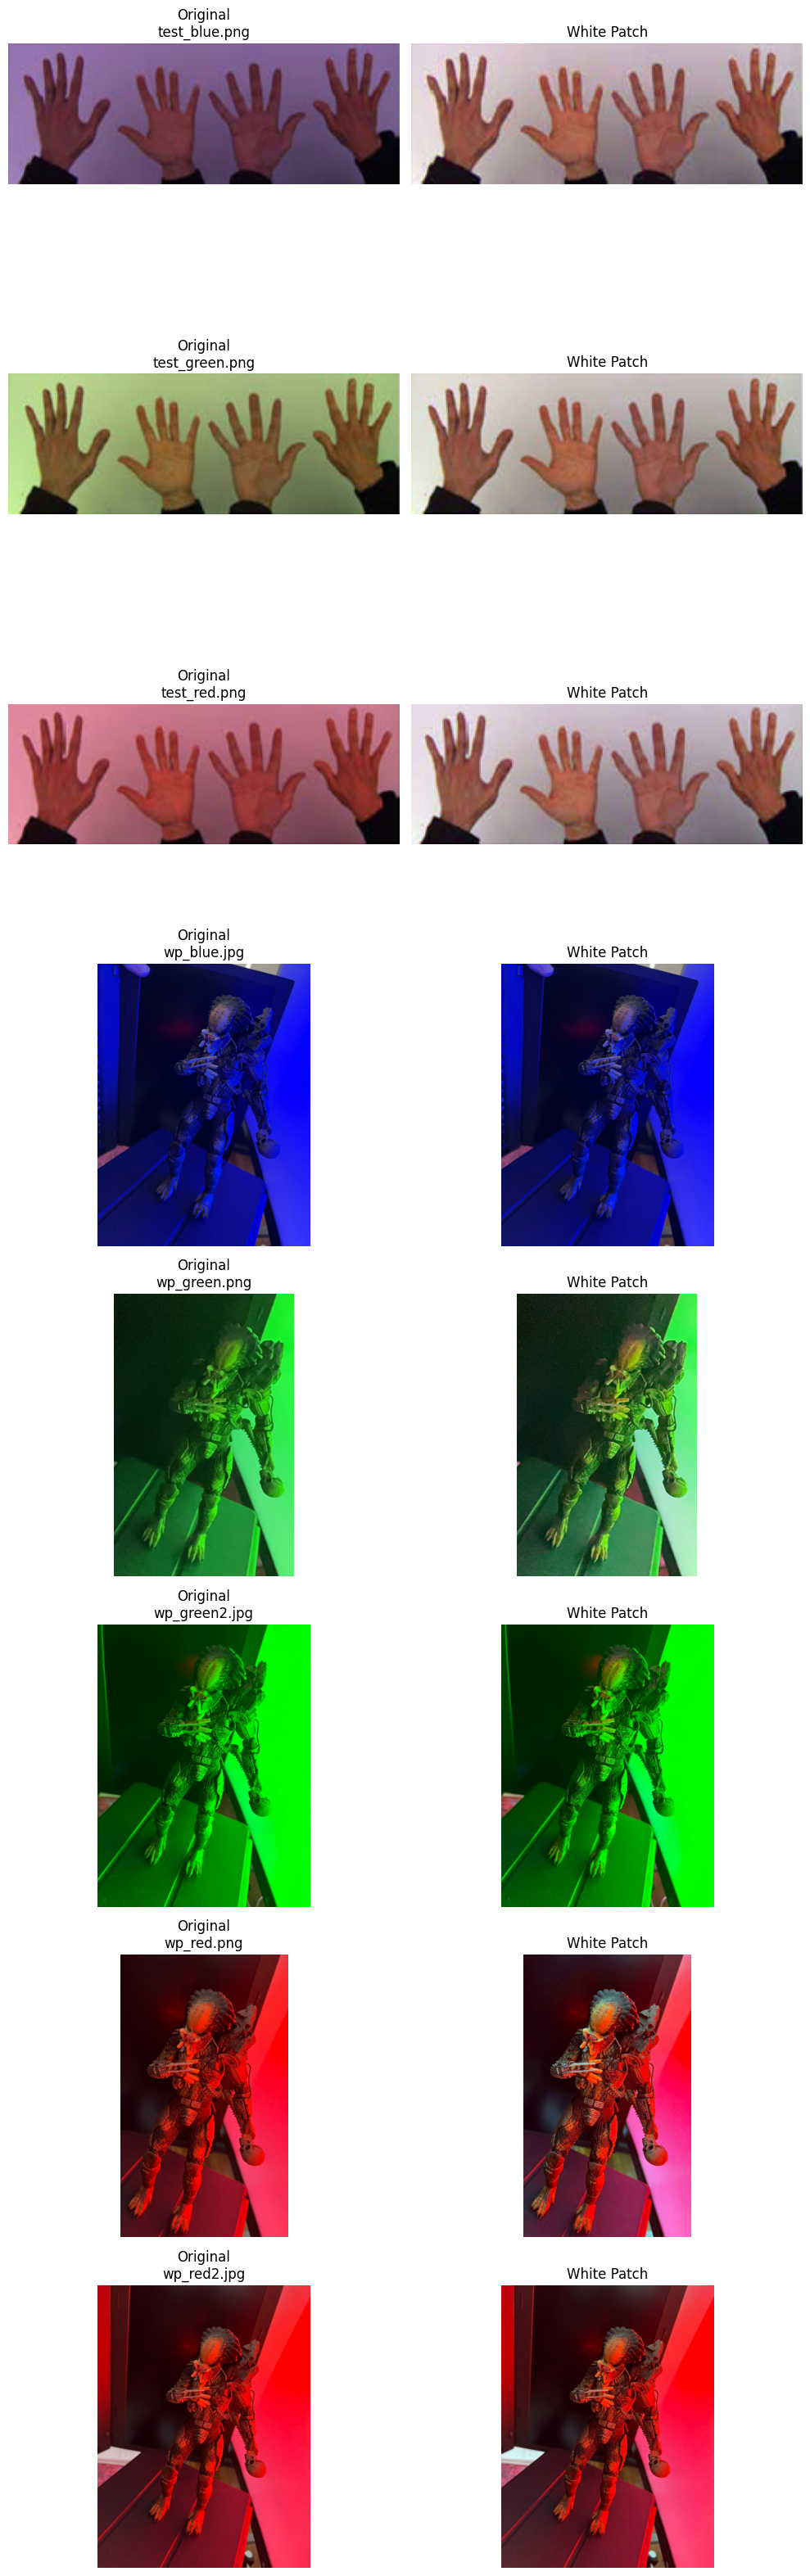

In [5]:
# Leer archivos de la carpeta
folder = Path("white_patch")
ext = {".png", ".jpg"}
image_paths = sorted([p for p in folder.iterdir() if p.suffix.lower() in ext])

print(f"Encontradas {len(image_paths)} imágenes")

# Procesar todas
originales = []
corregidas = []
nombres = []

for path in image_paths:
    img = cv2.imread(str(path))
    if img is None:
        print(f"No se pudo leer: {path.name}")
        continue

    wp = white_patch(img)

    # Convertir BGR -> RGB para matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    wp_rgb = cv2.cvtColor(wp, cv2.COLOR_BGR2RGB)

    originales.append(img_rgb)
    corregidas.append(wp_rgb)
    nombres.append(path.name)

# Mostrar grilla
n = len(corregidas)
if n == 0:
    print("No hay imágenes válidas para mostrar.")
else:
    fig, axes = plt.subplots(n, 2, figsize=(10, 4 * n))
    
    # Si solo hay una imagen, axes no es matriz
    if n == 1:
        axes = np.array([axes])

    for i in range(n):
        axes[i, 0].imshow(originales[i])
        axes[i, 0].set_title(f"Original\n{nombres[i]}")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(corregidas[i])
        axes[i, 1].set_title("White Patch")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()

### Resultados de White-patch
El algoritmo White Patch presenta limitaciones importantes cuando la escena no contiene un blanco real o cuando la iluminación es fuertemente monocromática. En estos casos, la suposición de que el valor máximo corresponde al blanco no se cumple, produciendo correcciones incorrectas. Por ejemplo en wp_blue.jpg: todo está iluminado en azul, wp_green.png: iluminación verde dominante, wp_red.png: iluminación roja muy fuerte. Funcionó bien en test_blue / green / red pero falló en wp_blue, wp_green, wp_green2. 
 Además, el método es altamente sensible a valores atípicos y puede generar sobrecompensación y pérdida de detalle debido al clipping. Por lo tanto, aunque es simple y eficiente, no es robusto frente a condiciones de iluminación complejas.

In [ ]:
def white_patch_corregido(img_bgr, percentile=99):
    img = img_bgr.astype(np.float32)

    # OpenCV trabaja en BGR
    b_ref = np.percentile(img[:, :, 0], percentile)
    g_ref = np.percentile(img[:, :, 1], percentile)
    r_ref = np.percentile(img[:, :, 2], percentile)

    # Evitar división por cero
    b_scale = 255.0 / b_ref if b_ref > 0 else 1.0
    g_scale = 255.0 / g_ref if g_ref > 0 else 1.0
    r_scale = 255.0 / r_ref if r_ref > 0 else 1.0

    img[:, :, 0] *= b_scale
    img[:, :, 1] *= g_scale
    img[:, :, 2] *= r_scale

    return np.clip(img, 0, 255).astype(np.uint8)

## Lectura de imagenes con OpenCV en escala de grises

True True


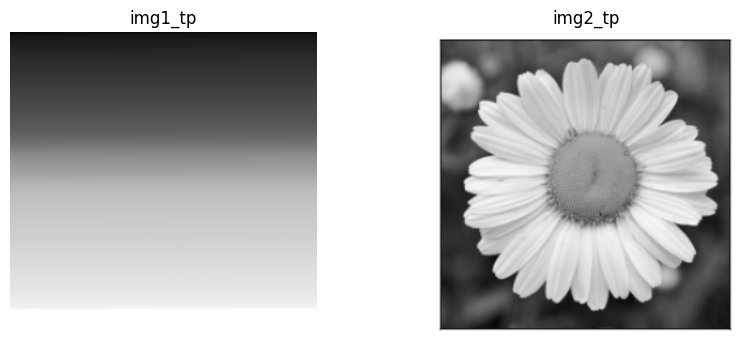

In [6]:
import cv2
import matplotlib.pyplot as plt

# Leer en escala de grises
img1 = cv2.imread("img1_tp.png", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("img2_tp.png", cv2.IMREAD_GRAYSCALE)

# Verificar que se cargaron bien
print(img1 is not None, img2 is not None)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img1, cmap='gray')
plt.title("img1_tp")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img2, cmap='gray')
plt.title("img2_tp")
plt.axis("off")

plt.show()
